# Housing Supply

> Housing supply functions, elasticity, and equilibrium rent determination


In [ ]:
# | default_exp housing

In [ ]:
# | export
import numpy as np

## Where Do Rents Come From?

In the Rosen-Roback model, rents are determined by the **housing market**. Supply meets demand:

- **Supply**: Developers build housing when rents are high
- **Demand**: Workers need housing (assume 1 unit per worker)
- **Equilibrium**: Housing supply = Housing demand (= population)

## The Housing Supply Function

Housing supply responds to rents:

$$H = S \cdot r^{\gamma}$$

where:

- $H$ = housing units supplied
- $S$ = supply shifter (land availability, construction costs)
- $r$ = rent
- $\gamma$ = **supply elasticity**

### What is Supply Elasticity?

The elasticity $\gamma$ measures how responsive supply is to price:

$$\gamma = \frac{\% \Delta H}{\% \Delta r}$$

**Examples** (from Saiz 2010):

- **Houston**: $\gamma \approx 2.5$ (very elastic - flat land, few regulations)
- **Chicago**: $\gamma \approx 1.1$ (moderate)
- **Los Angeles**: $\gamma \approx 0.76$ (inelastic - geography + regulations)
- **San Francisco**: $\gamma \approx 0.66$ (very inelastic - peninsula + strict zoning)

**Why does elasticity vary?**

- Geography: mountains, water bodies limit building
- Regulations: zoning, height limits, environmental reviews
- Land availability: room to sprawl vs. built-up

## Equilibrium Rent

In equilibrium, housing supply equals population:

$$H = L$$

Solving for rent:

$$r = \left(\frac{L}{S}\right)^{1/\gamma}$$

**Key insight**: When supply is inelastic (low $\gamma$), the exponent $1/\gamma$ is large, so rent increases sharply with population.


In [ ]:
# | export
def housing_supply(
    rent: float,  # Housing rent
    supply_shifter: float,  # Supply shifter parameter (S)
    elasticity: float,  # Supply elasticity (gamma)
) -> float:
    """Calculate housing supply given rent and supply parameters."""
    return supply_shifter * (rent**elasticity)


def equilibrium_rent(
    population: float,  # City population (= housing demand)
    supply_shifter: float,  # Supply shifter parameter (S)
    elasticity: float,  # Supply elasticity (gamma)
) -> float:
    """Calculate equilibrium rent where housing supply equals population."""
    return (population / supply_shifter) ** (1 / elasticity)


def rent_elasticity_with_respect_to_population(
    population: float,  # Current population
    supply_shifter: float,  # Supply shifter parameter
    elasticity: float,  # Supply elasticity (gamma)
) -> float:
    """Calculate the elasticity of rent with respect to population."""
    return 1 / elasticity

Examples:

In [ ]:
# Calculate housing supply at a given rent
h = housing_supply(rent=100, supply_shifter=1000, elasticity=2.0)
assert h == 1000 * (100**2.0)

# Calculate equilibrium rent where supply equals 1M population
r = equilibrium_rent(population=1_000_000, supply_shifter=1_000_000, elasticity=2.0)
assert np.isclose(r, 1.0)  # Should be 1 when pop = shifter

# Verify equilibrium condition: H = L
h_eq = housing_supply(r, 1_000_000, 2.0)
assert np.isclose(h_eq, 1_000_000)

## The Power of Elasticity

Let's see how different supply elasticities affect the rent response to population growth.


In [ ]:
# Compare rent response across cities with different elasticities
supply_shifter = 1_000_000  # Calibrated so rent ≈ 1 at 1M population with gamma=2
base_population = 1_000_000
new_population = 1_500_000  # 50% population growth

# Empirical elasticities from Saiz (2010)
cities = [
    ("Houston", 2.55),
    ("Austin", 1.63),
    ("Chicago", 1.12),
    ("Los Angeles", 0.76),
    ("San Francisco", 0.66),
]

print("Effect of 50% Population Growth on Rents")
print("=" * 70)
print(f"{'City':<20} {'Elasticity (γ)':>15} {'Initial Rent':>12} {'New Rent':>12} {'% Increase':>12}")
print("-" * 70)

for city_name, gamma in cities:
    initial_rent = equilibrium_rent(base_population, supply_shifter, gamma)
    new_rent = equilibrium_rent(new_population, supply_shifter, gamma)
    pct_increase = (new_rent / initial_rent - 1) * 100

    print(f"{city_name:<20} {gamma:>15.2f} {initial_rent:>12.2f} {new_rent:>12.2f} {pct_increase:>11.1f}%")

print("-" * 70)
print("\nKey insight: Inelastic cities (low γ) see much larger rent increases!")

Effect of 50% Population Growth on Rents
City                  Elasticity (γ) Initial Rent     New Rent   % Increase
----------------------------------------------------------------------
Houston                         2.55         1.00         1.17        17.2%
Austin                          1.63         1.00         1.28        28.2%
Chicago                         1.12         1.00         1.44        43.6%
Los Angeles                     0.76         1.00         1.70        70.5%
San Francisco                   0.66         1.00         1.85        84.8%
----------------------------------------------------------------------

Key insight: Inelastic cities (low γ) see much larger rent increases!


## Rent Elasticity

The elasticity of rent with respect to population is simply $1/\gamma$. This tells us how much rents respond to population changes.


In [5]:
print("Rent Elasticity with Respect to Population")
print("=" * 70)
print(f"{'City':<20} {'Supply Elasticity (γ)':>25} {'Rent Elasticity (1/γ)':>25}")
print("-" * 70)

for city_name, gamma in cities:
    rent_elast = 1 / gamma
    print(f"{city_name:<20} {gamma:>25.2f} {rent_elast:>25.2f}")

print("-" * 70)
print("\nInterpretation: In San Francisco (γ=0.66), a 1% population increase")
print("                causes a 1.5% rent increase.")
print("                In Houston (γ=2.55), the same 1% increase")
print("                causes only a 0.4% rent increase.")

Rent Elasticity with Respect to Population
City                     Supply Elasticity (γ)     Rent Elasticity (1/γ)
----------------------------------------------------------------------
Houston                                   2.55                      0.39
Austin                                    1.63                      0.61
Chicago                                   1.12                      0.89
Los Angeles                               0.76                      1.32
San Francisco                             0.66                      1.52
----------------------------------------------------------------------

Interpretation: In San Francisco (γ=0.66), a 1% population increase
                causes a 1.5% rent increase.
                In Houston (γ=2.55), the same 1% increase
                causes only a 0.4% rent increase.


## Tests


In [ ]:
# | hide
# Test housing supply function
h = housing_supply(rent=100, supply_shifter=1000, elasticity=2.0)
assert np.isclose(h, 1000 * (100**2.0))

# Test equilibrium rent
r = equilibrium_rent(population=1_000_000, supply_shifter=1_000_000, elasticity=2.0)
assert np.isclose(r, 1.0)  # Should be 1 when pop = shifter

# Test that equilibrium rent satisfies H = L
pop = 1_500_000
shifter = 1_000_000
gamma = 1.5
r_eq = equilibrium_rent(pop, shifter, gamma)
h_eq = housing_supply(r_eq, shifter, gamma)
assert np.isclose(h_eq, pop, rtol=0.01)

# Test that lower elasticity → higher rent sensitivity
r_elastic = equilibrium_rent(2_000_000, 1_000_000, 2.0)
r_inelastic = equilibrium_rent(2_000_000, 1_000_000, 0.5)
assert r_inelastic > r_elastic

# Test rent elasticity formula
assert np.isclose(rent_elasticity_with_respect_to_population(1e6, 1e6, 2.0), 0.5)
assert np.isclose(rent_elasticity_with_respect_to_population(1e6, 1e6, 0.5), 2.0)

## Visualizing Supply Curves

Let's plot housing supply curves for different elasticities.


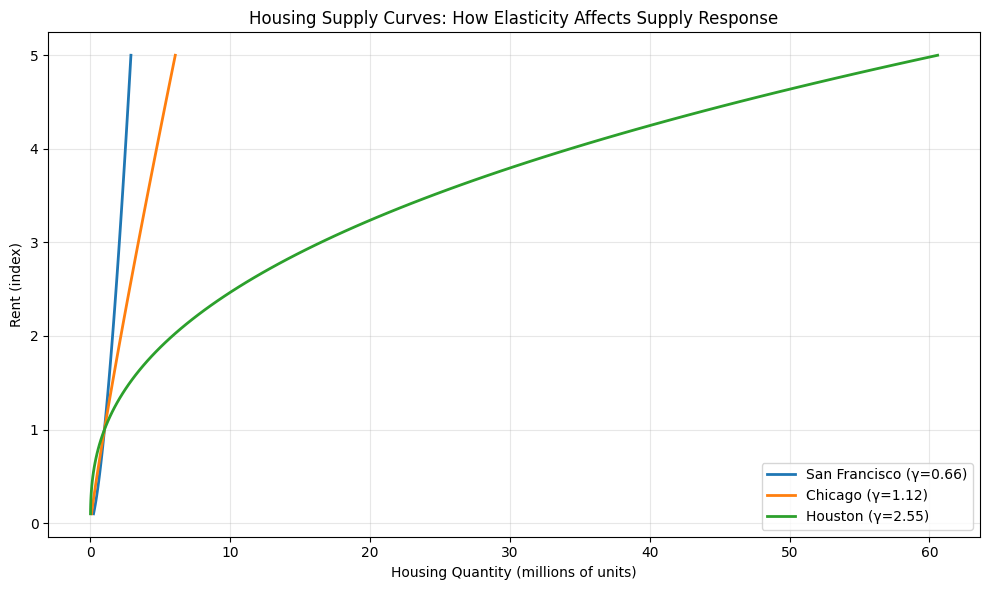

In [7]:
# This cell would create a visualization if matplotlib is available
try:
    import matplotlib.pyplot as plt

    rents = np.linspace(0.1, 5, 100)
    supply_shifter = 1_000_000

    fig, ax = plt.subplots(figsize=(10, 6))

    for gamma, label in [(0.66, "San Francisco (γ=0.66)"), (1.12, "Chicago (γ=1.12)"), (2.55, "Houston (γ=2.55)")]:
        quantities = [housing_supply(r, supply_shifter, gamma) for r in rents]
        ax.plot(np.array(quantities) / 1e6, rents, label=label, linewidth=2)

    ax.set_xlabel("Housing Quantity (millions of units)")
    ax.set_ylabel("Rent (index)")
    ax.set_title("Housing Supply Curves: How Elasticity Affects Supply Response")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Matplotlib not available for visualization")

## Key Insights

1. **Supply elasticity is crucial**: It determines how much rents rise when population increases
2. **Inelastic supply → rent spikes**: Cities with geographic or regulatory constraints see explosive rent growth
3. **Elastic supply → stable rents**: Cities with room to build can absorb population growth
4. **Policy matters**: Zoning and planning regulations directly affect $\gamma$

### Why This Matters for Policy

**If a productive city has inelastic housing supply**:

- Workers face high rents
- Many workers are priced out
- They move to less productive cities
- **National GDP falls**

This is the mechanism behind the Hsieh-Moretti (2019) finding that housing constraints in high-productivity cities reduce U.S. GDP by 3.7-8.9%.


In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()